# Week 11 · Day 1 — RNNs & Sentiment Analysis

Yesterday we saw *why* sequences need special models. Today we build one: an **RNN** that reads a movie review word-by-word and decides if it's **positive or negative**.

The full pipeline, bottom-up:
1. **Text → numbers** — tokenize, integer-encode, pad to equal length.
2. **Embeddings** — turn word-integers into meaningful vectors (the `Embedding` layer).
3. **The RNN** — read the sequence, carry a memory, output one sentiment.
4. **Train on IMDB** — 25,000 real movie reviews.
5. **Read the results** — including an honest look at where the SimpleRNN struggles (→ tomorrow's LSTM).

> **Kaggle GPU:** Settings → Accelerator → GPU. IMDB downloads automatically (needs internet on).

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input

tf.random.set_seed(42)
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.18.1
GPUs: []


---
## 1. Text → numbers

A network can't read words — only numbers. Let's convert some tiny example sentences first, so every step is visible, before touching the big dataset.

In [2]:
docs = ['go pakistan',
        'pakistan pakistan',
        'dil dil pakistan',
        'jeetega bhai jeetega pakistan jeetega',
        'pakistan zindabad',
        'babar babar',
        'shaheen shaheen',
        'afridi afridi',
        'quaid e azam zindabad',
        'hum honge kamyab']

### Step 1a: build a vocabulary (tokenize)
The **tokenizer** scans all the text and assigns each unique word an integer ID. This mapping is the vocabulary.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(docs)

print("vocabulary size:", len(tokenizer.word_index))
print("\nword -> integer map:")
print(tokenizer.word_index)

vocabulary size: 15

word -> integer map:
{'pakistan': 1, 'jeetega': 2, 'dil': 3, 'zindabad': 4, 'babar': 5, 'shaheen': 6, 'afridi': 7, 'go': 8, 'bhai': 9, 'quaid': 10, 'e': 11, 'azam': 12, 'hum': 13, 'honge': 14, 'kamyab': 15}


### Step 1b: integer-encode the sentences
Now replace each word with its integer. A sentence becomes a **list of integers** — a sequence the model can work with.

In [6]:
sequences = tokenizer.texts_to_sequences(docs)

for doc, seq in zip(docs, sequences):
    print(f"{doc:38s} -> {seq}")

go pakistan                            -> [8, 1]
pakistan pakistan                      -> [1, 1]
dil dil pakistan                       -> [3, 3, 1]
jeetega bhai jeetega pakistan jeetega  -> [2, 9, 2, 1, 2]
pakistan zindabad                      -> [1, 4]
babar babar                            -> [5, 5]
shaheen shaheen                        -> [6, 6]
afridi afridi                          -> [7, 7]
quaid e azam zindabad                  -> [10, 11, 12, 4]
hum honge kamyab                       -> [13, 14, 15]


### Step 1c: pad to equal length
Sentences have different lengths, but the model needs a **rectangular** batch. **Padding** adds 0s so every sequence is the same length. `padding='post'` puts the zeros at the end.

In [7]:
padded = pad_sequences(sequences, padding='post')
print("all sequences now the same length:\n")
print(padded)

all sequences now the same length:

[[ 8  1  0  0  0]
 [ 1  1  0  0  0]
 [ 3  3  1  0  0]
 [ 2  9  2  1  2]
 [ 1  4  0  0  0]
 [ 5  5  0  0  0]
 [ 6  6  0  0  0]
 [ 7  7  0  0  0]
 [10 11 12  4  0]
 [13 14 15  0  0]]


> **Recap of yesterday's lesson:** these integers are just IDs — `india=1` isn't "less than" `hurray=10`. They carry **no meaning** on their own. That's the job of the next step: embeddings.

---
## 2. Embeddings: integers → meaningful vectors

The **`Embedding` layer** is a lookup table: it maps each word-integer to a **dense vector** of learnable numbers. During training these vectors organize so that similar words get similar vectors — meaning emerges.

Here we make a tiny embedding (each word → a 2-number vector) just to *see* the shape of what it produces.

In [8]:
vocab_size = len(tokenizer.word_index) + 1   # +1 because integer 0 is reserved for padding

demo = Sequential([
    Input(shape=(padded.shape[1],)),
    Embedding(input_dim=vocab_size, output_dim=2)   # each word -> a 2-D vector
])
demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 2)           │            32 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32 (128.00 B)

 Trainable params: 32 (128.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
demo = Sequential([
    Input(shape=(padded.shape[1],)),
    Embedding(input_dim=vocab_size, output_dim=2),   # each word -> a 2-D vector
    SimpleRNN(2)
])
demo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 5, 2)           │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42 (168.00 B)

 Trainable params: 42 (168.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
emb_vectors = demo.predict(padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step


In [36]:
emb_vectors

array([[-0.01411966,  0.07486862],
       [-0.02714607,  0.09361969],
       [-0.03107425,  0.08879449],
       [ 0.04734713,  0.01981174],
       [-0.0531315 , -0.00782648],
       [ 0.00781683, -0.08463763],
       [ 0.00728637, -0.08194848],
       [-0.00172038, -0.0358888 ],
       [ 0.01140833, -0.1000305 ],
       [ 0.0661703 ,  0.02413681]], dtype=float32)

In [12]:
emb_vectors[1]

array([[0.00143983, 0.02507013],
       [0.00143983, 0.02507013],
       [0.03492621, 0.02481369],
       [0.03492621, 0.02481369],
       [0.03492621, 0.02481369]], dtype=float32)

In [13]:
emb_vectors[2]

array([[-0.03891407, -0.04046429],
       [-0.03891407, -0.04046429],
       [ 0.00143983,  0.02507013],
       [ 0.03492621,  0.02481369],
       [ 0.03492621,  0.02481369]], dtype=float32)

In [14]:
emb_vectors.shape

(10, 5, 2)

In [12]:
# what does the embedding layer output for our padded sentences?
vectors = demo.predict(padded, verbose=0)
print("input shape :", padded.shape, "(10 sentences x 5 words)")
print("output shape:", vectors.shape, "(10 sentences x 5 words x 2 numbers each)")
print("\nfirst sentence's word-vectors:\n", vectors[0])

input shape : (10, 5) (10 sentences x 5 words)
output shape: (10, 5, 2) (10 sentences x 5 words x 2 numbers each)

first sentence's word-vectors:
 [[ 0.04591172 -0.01419884]
 [ 0.03699331  0.04856646]
 [-0.01556848  0.03577233]
 [-0.01556848  0.03577233]
 [-0.01556848  0.03577233]]


Each word is now a small vector. The values are random for now (untrained) — but when we train the full model, these vectors become meaningful. **This layer is the first layer of almost every NLP model.**

---
## 3. The RNN, conceptually

An **RNN** reads the embedded words **one at a time**, keeping a running **hidden state** (its memory of the sentence so far). After the last word, that hidden state summarizes the whole sentence — and we use it to decide the sentiment.

```
 word1 -> [RNN] -> word2 -> [RNN] -> word3 -> [RNN] -> ... -> final memory -> positive/negative
            ↑_______________↑_______________↑   (same weights reused each step)
```

That's a **many-to-one** model (yesterday's taxonomy): a sequence in, a single label out. Now we build it for real, on real reviews.

---
## 4. Sentiment analysis on IMDB

**IMDB**: 25,000 training + 25,000 test movie reviews, each labeled **positive (1)** or **negative (0)**. It comes **already integer-encoded** (Keras did the tokenizing for us), so we jump straight to padding.

In [27]:
from tensorflow.keras.datasets import imdb

VOCAB = 10000   # keep only the 10,000 most common words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB)

print("train reviews:", len(X_train), " test reviews:", len(X_test))
print("first review (already integers):", X_train[0][:15], "...")
print("its label:", y_train[0], "(1 = positive, 0 = negative)")

train reviews: 25000  test reviews: 25000
first review (already integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...
its label: 1 (1 = positive, 0 = negative)


In [32]:
len(X_train[3])

550

In [33]:
# reviews vary in length — pad/truncate them all to 50 words
MAXLEN = 50
X_train = pad_sequences(X_train, padding='post', maxlen=MAXLEN)
X_test  = pad_sequences(X_test,  padding='post', maxlen=MAXLEN)
print("padded train shape:", X_train.shape)   # (25000, 50)

padded train shape: (25000, 50)


### Build the model
Three layers, exactly the pipeline we built up:
- **`Embedding`** — each word-integer → a 32-D vector.
- **`SimpleRNN(32)`** — reads the sequence, carries a 32-number memory, outputs the final memory.
- **`Dense(1, sigmoid)`** — turns that memory into a probability (positive vs negative).

In [38]:
model = Sequential([
    Input(shape=(MAXLEN,)),
    Embedding(input_dim=VOCAB, output_dim=32),   # note: (input_dim, output_dim) — modern Keras
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test))

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6561 - loss: 0.6022 - val_accuracy: 0.8017 - val_loss: 0.4416
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8482 - loss: 0.3555 - val_accuracy: 0.7889 - val_loss: 0.4521
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9055 - loss: 0.2486 - val_accuracy: 0.7296 - val_loss: 0.5727
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9425 - loss: 0.1638 - val_accuracy: 0.7783 - val_loss: 0.5803
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9734 - loss: 0.0929 - val_accuracy: 0.7890 - val_loss: 0.6843


In [40]:
h = history.history
h

{'accuracy': [0.7326800227165222,
  0.8574000000953674,
  0.9133999943733215,
  0.9464799761772156,
  0.972320020198822],
 'loss': [0.5261066555976868,
  0.34055766463279724,
  0.2345716804265976,
  0.1505936086177826,
  0.09120852500200272],
 'val_accuracy': [0.8016800284385681,
  0.788919985294342,
  0.7295600175857544,
  0.7782800197601318,
  0.7889999747276306],
 'val_loss': [0.4416489899158478,
  0.4521450698375702,
  0.5726591944694519,
  0.5802547931671143,
  0.6842884421348572]}

## 5. Read the results

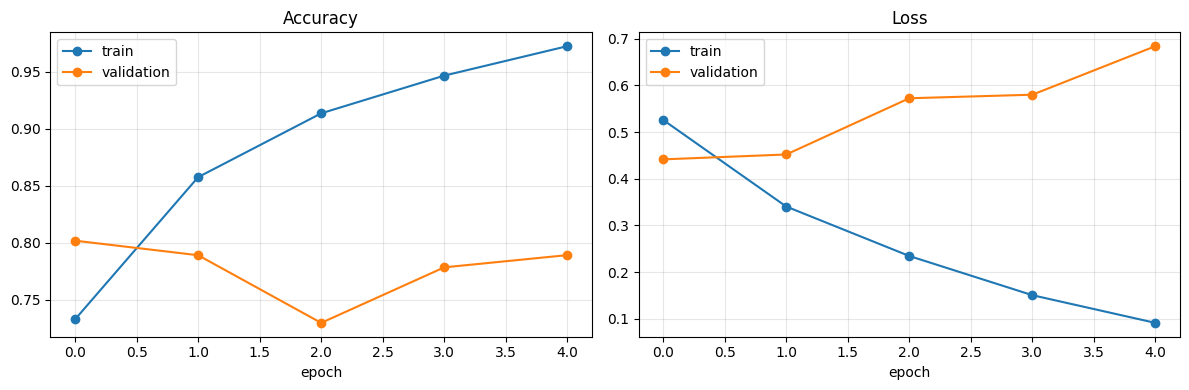

final train accuracy:      97.23%
final validation accuracy: 78.90%


In [41]:
import matplotlib.pyplot as plt

h = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(h['accuracy'], marker='o', label='train')
ax1.plot(h['val_accuracy'], marker='o', label='validation')
ax1.set_title('Accuracy'); 
ax1.set_xlabel('epoch'); 
ax1.legend(); 
ax1.grid(alpha=0.3)


ax2.plot(h['loss'], marker='o', label='train')
ax2.plot(h['val_loss'], marker='o', label='validation')
ax2.set_title('Loss'); 
ax2.set_xlabel('epoch'); 
ax2.legend(); 
ax2.grid(alpha=0.3)
plt.tight_layout(); 
plt.show()

print(f"final train accuracy:      {h['accuracy'][-1]:.2%}")
print(f"final validation accuracy: {h['val_accuracy'][-1]:.2%}")

In [42]:
imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

### The honest lesson (this sets up tomorrow)
Look at the two curves. You'll likely see **train accuracy shoot up while validation accuracy stalls or drops** — the SimpleRNN **memorizes** the training reviews but doesn't generalize well. Two reasons:

- We cut every review to **50 words** — a lot of a review's sentiment gets thrown away.
- A **SimpleRNN forgets** — over a long review its early-word memory fades (the vanishing-gradient-over-time problem). It can't hold a long-range "this movie was NOT good" dependency.

**That forgetting is exactly what LSTMs and GRUs fix — tomorrow.**

### Try it on your own text (optional)
Decode the word index so we can feed a custom sentence through the trained model.

In [43]:
word_index = imdb.get_word_index()
# imdb reserves 0=pad, 1=start, 2=unknown, so real word ids are shifted by 3
def encode(text):
    ids = [1]  # start token
    for w in text.lower().split():
        idx = word_index.get(w, -1)
        ids.append(idx + 3 if 0 <= idx < VOCAB - 3 else 2)   # 2 = unknown
    return pad_sequences([ids], padding='post', maxlen=MAXLEN)



In [44]:
encode("this movie was fantastic and i loved every minute")

array([[  1,  14,  20,  16, 777,   5,  13, 447, 175, 786,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]],
      dtype=int32)

In [45]:
for review in ["this movie was fantastic and i loved every minute",
               "terrible boring waste of time i hated it"]:
    p = model.predict(encode(review), verbose=0)[0][0]
    print(f"'{review}'\n  -> {p:.2f}  ({'positive' if p > 0.5 else 'negative'})\n")

'this movie was fantastic and i loved every minute'
  -> 0.98  (positive)

'terrible boring waste of time i hated it'
  -> 0.01  (negative)



In [47]:
X_test[0]

array([ 394,  354,    4,  123,    9, 1035, 1035, 1035,   10,   10,   13,
         92,  124,   89,  488, 7944,  100,   28, 1668,   14,   31,   23,
         27, 7479,   29,  220,  468,    8,  124,   14,  286,  170,    8,
        157,   46,    5,   27,  239,   16,  179,    2,   38,   32,   25,
       7944,  451,  202,   14,    6,  717], dtype=int32)

---
## Your turn (solo task) ✍️

Pick at least two:
1. **Increase `MAXLEN`** to 200. Does keeping more of each review help validation accuracy?
2. **Change the embedding size** (`output_dim`) to 8 or 64 — effect on accuracy and training time?
3. **Add a second `SimpleRNN`** (use `return_sequences=True` on the first one). Does depth help?
4. **Write 3 of your own reviews** and test them with the `encode()` helper — where does the model get confused?
5. **Reduce `VOCAB`** to 5000 — does a smaller vocabulary hurt?

In [ ]:
# ===== YOUR EXPERIMENTS HERE =====



---
## Summary

- **Text → numbers:** tokenize (word → integer), integer-encode sentences, **pad** to equal length.
- **Embedding layer:** maps each word-integer to a learnable **dense vector** — the first layer of NLP models. Integers alone carry no meaning; embeddings do.
- **SimpleRNN:** reads the sequence one word at a time, carrying a **hidden-state memory**; the final memory → a sentiment (**many-to-one**).
- Trained on **IMDB** — it learns, but the SimpleRNN **overfits and forgets** long reviews.
- That forgetting motivates **LSTM & GRU**, which we build tomorrow.

**Tomorrow (Day 2):** the memory problem — LSTMs and GRUs that remember across long sequences.